# Phase 1: Synthetic Data Baselines (Backpropagation)
In this phase, we establish a baseline using standard backpropagation on a 2D synthetic dataset. The dataset is intentionally designed so that its natural visual shape (left/right clusters) contradicts its assigned class labels (top/bottom).

In [1]:
import sys
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
sys.path.append(os.path.abspath('..'))
from utils.synthetic_data import *
from utils.plots import *
from models.baseline_bp import *
from models.pepita import *
from models.softhebb import *

## 1. Generate and Load the Data
We load the misaligned data and prepare it for PyTorch.

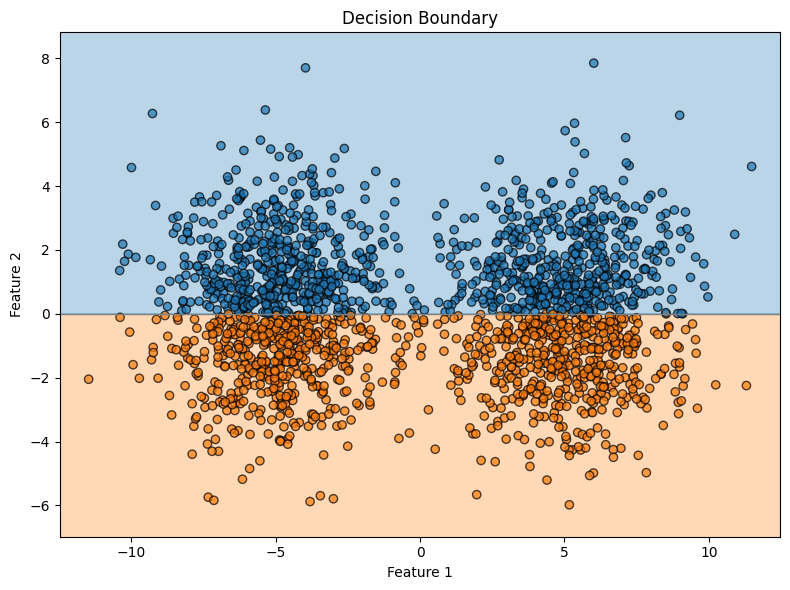

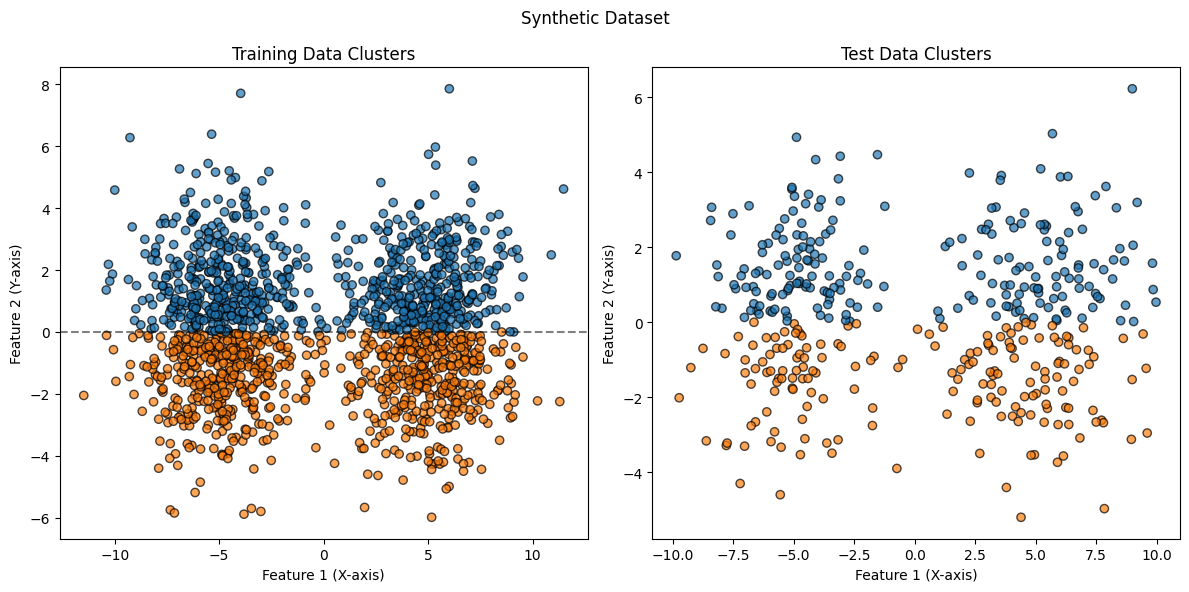

In [2]:
random_state = 42

X, y = generate_synthetic_data(n_samples=2000, cluster_std=2, centers=[[-5.0, 0.0], [5.0, 0.0]], random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# plot_synthetic_data(X_train, y_train, X_test, y_test)
plot_initial_dataset_boundary(X_train, y_train, X_test, y_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=custom_cmap, alpha=0.7, edgecolors='k')
ax1.set_title("Training Data Clusters")
ax1.set_xlabel("Feature 1 (X-axis)")
ax1.set_ylabel("Feature 2 (Y-axis)")
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)

ax2.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=custom_cmap, alpha=0.7, edgecolors='k')
ax2.set_title("Test Data Clusters")
ax2.set_xlabel("Feature 1 (X-axis)")
ax2.set_ylabel("Feature 2 (Y-axis)")

plt.suptitle("Synthetic Dataset")
plt.tight_layout()
plt.show()

## 2. Train the Baseline Model
This is the standard BP training loop, defined in `models/baseline_bp.py`.

Epoch 10/50 | Train Loss: 0.0922 | Train Acc: 99.19% | Test Loss: 0.0975 | Test Acc: 98.75%
Epoch 20/50 | Train Loss: 0.0575 | Train Acc: 99.25% | Test Loss: 0.0683 | Test Acc: 98.25%
Epoch 30/50 | Train Loss: 0.0448 | Train Acc: 99.50% | Test Loss: 0.0527 | Test Acc: 99.25%
Epoch 40/50 | Train Loss: 0.0380 | Train Acc: 99.31% | Test Loss: 0.0422 | Test Acc: 99.50%
Epoch 50/50 | Train Loss: 0.0331 | Train Acc: 99.75% | Test Loss: 0.0406 | Test Acc: 99.25%


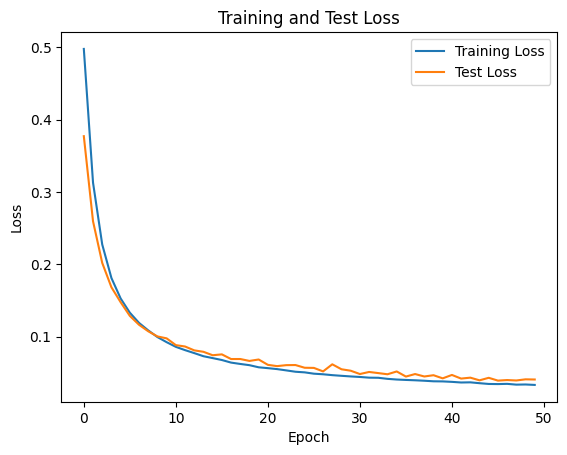

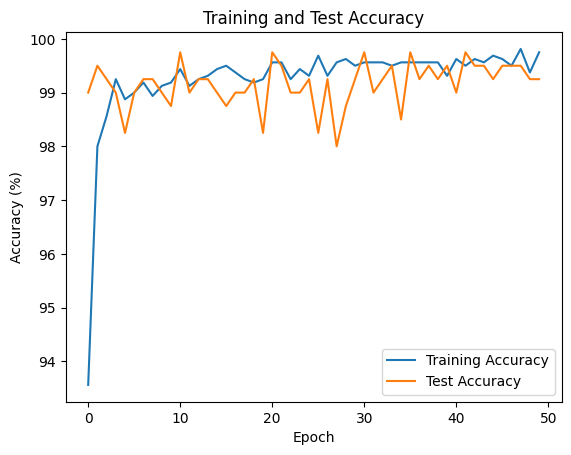

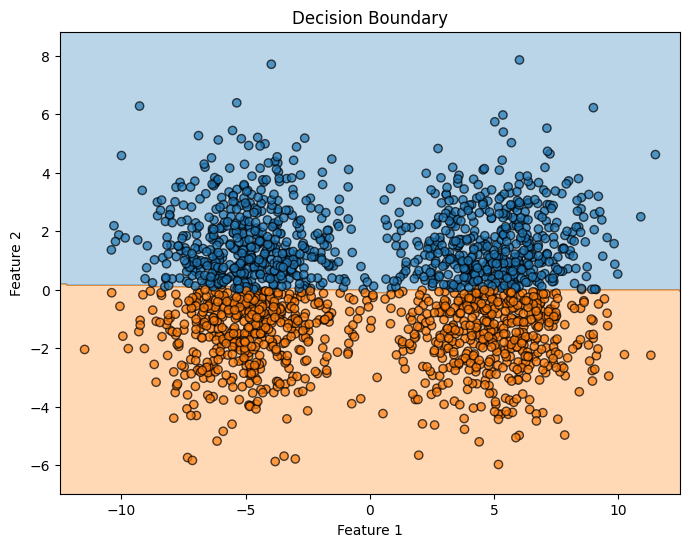

In [3]:
bp_model = BaselineMLP(input_dim=2, hidden_dim=64, output_dim=2)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(bp_model.parameters(), lr=0.01)
epochs = 50

bp_train_loss, bp_train_acc, bp_test_loss, bp_test_acc = train_bp_model(bp_model, train_dataloader, test_dataloader, criterion, optimizer, epochs=epochs)

plot_loss(bp_train_loss, bp_test_loss)
plot_accuracy(bp_train_acc, bp_test_acc)
plot_decision_boundary(bp_model, X_train, y_train, X_test, y_test)

## 3. Train the SoftHebb Model

This is the SoftHebb Model from this github repository, adapted for 2D.

Epoch 10/50 | Train Loss: 0.4542 | Train Acc: 98.31% | Test Loss: 0.4498 | Test Acc: 98.25%
Epoch 20/50 | Train Loss: 0.4175 | Train Acc: 98.12% | Test Loss: 0.4175 | Test Acc: 99.50%
Epoch 30/50 | Train Loss: 0.4013 | Train Acc: 99.25% | Test Loss: 0.3996 | Test Acc: 99.00%
Epoch 40/50 | Train Loss: 0.3908 | Train Acc: 99.38% | Test Loss: 0.3914 | Test Acc: 99.00%
Epoch 50/50 | Train Loss: 0.3842 | Train Acc: 99.56% | Test Loss: 0.3838 | Test Acc: 99.25%


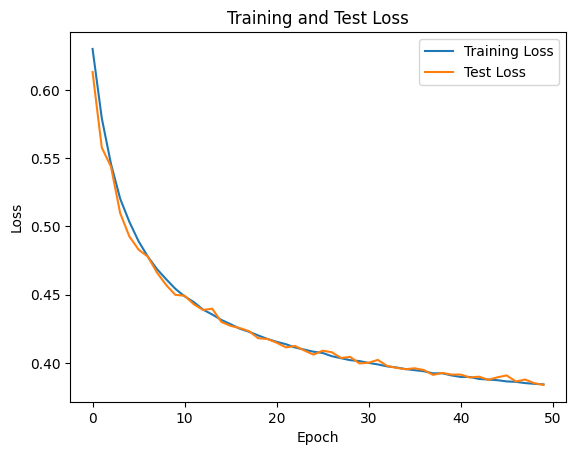

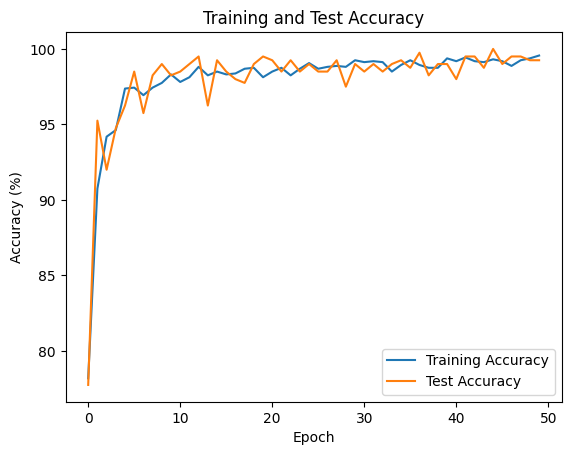

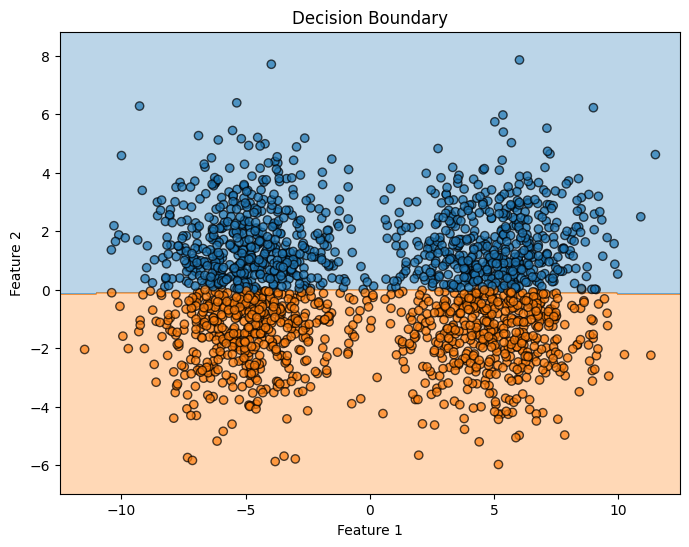

In [4]:
softhebb_model = SoftHebbMLP(input_dim=2, hidden_dim=64, output_dim=2)

softhebb_train_loss, softhebb_train_acc, softhebb_test_loss, softhebb_test_acc = train_softhebb_model(
    model=softhebb_model, 
    train_dataloader=train_dataloader, 
    test_dataloader=test_dataloader,
    criterion=nn.CrossEntropyLoss(), 
    optimizer_name='SGD', 
    epochs=epochs, 
    eta=0.01,
    t_invert=12.0 
)

plot_loss(softhebb_train_loss, softhebb_test_loss)
plot_accuracy(softhebb_train_acc, softhebb_test_acc)
plot_decision_boundary(softhebb_model, X_train, y_train, X_test, y_test)

## 4. Train the PEPITA Model

This is the PEPITA Model from [this github repository](https://github.com/GiorgiaD/PEPITA/tree/main), adapted for 2D.

Starting PEPITA training...
Epoch 10/50 | Train Loss: 0.4761 | Train Acc: 95.25% | Test Loss: 0.4803 | Test Acc: 93.50%
Epoch 20/50 | Train Loss: 0.4557 | Train Acc: 95.69% | Test Loss: 0.4609 | Test Acc: 93.75%
Epoch 30/50 | Train Loss: 0.4580 | Train Acc: 93.31% | Test Loss: 0.4653 | Test Acc: 91.50%
Epoch 40/50 | Train Loss: 0.4609 | Train Acc: 90.81% | Test Loss: 0.4694 | Test Acc: 88.75%
Epoch 50/50 | Train Loss: 0.4632 | Train Acc: 90.19% | Test Loss: 0.4720 | Test Acc: 88.75%


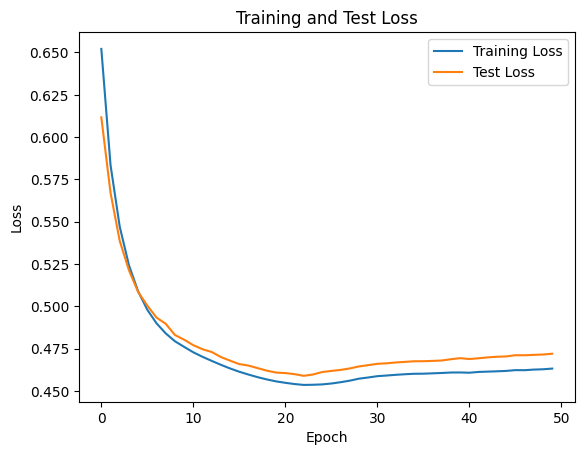

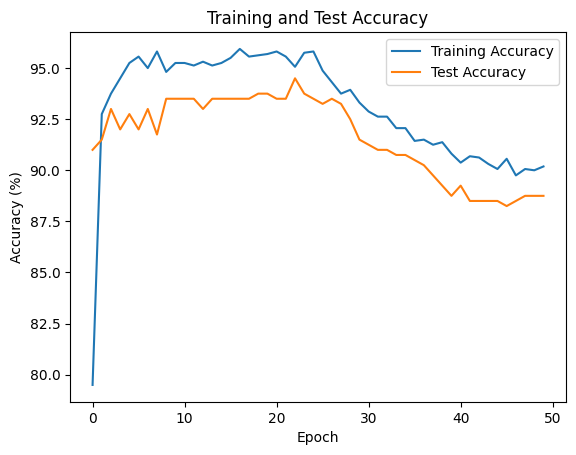

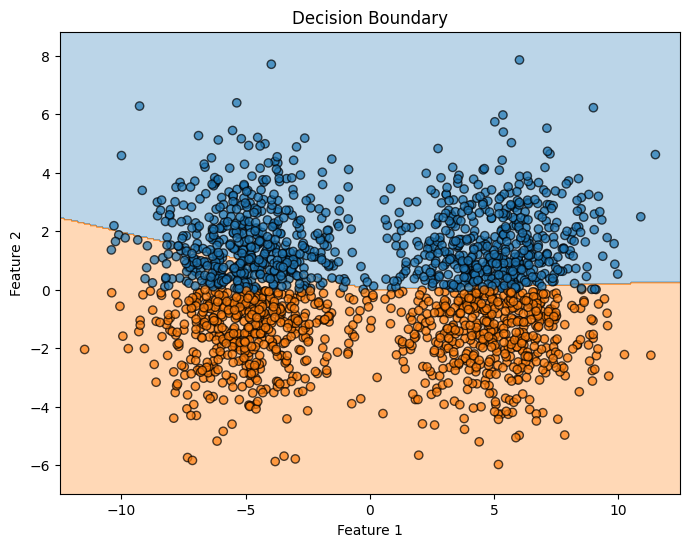

In [5]:
pepita_model = PepitaMLP(input_dim=2, hidden_dim=64, output_dim=2)

nin = 2   
nout = 2  
sd = np.sqrt(6 / nin)

B = (torch.rand(nin, nout) * 2 * sd - sd) * 0.05

print("Starting PEPITA training...")
pepita_train_loss, pepita_train_acc, pepita_test_loss, pepita_test_acc = train_pepita_model(
    model=pepita_model, 
    train_dataloader=train_dataloader, 
    test_dataloader=test_dataloader,
    B=B, 
    criterion=nn.CrossEntropyLoss(), 
    optimizer_name='SGD', 
    epochs=epochs, 
    eta=0.01
)

plot_loss(pepita_train_loss, pepita_test_loss)
plot_accuracy(pepita_train_acc, pepita_test_acc)
plot_decision_boundary(pepita_model, X_train, y_train, X_test, y_test)

## 5. Compare the results side-by-side

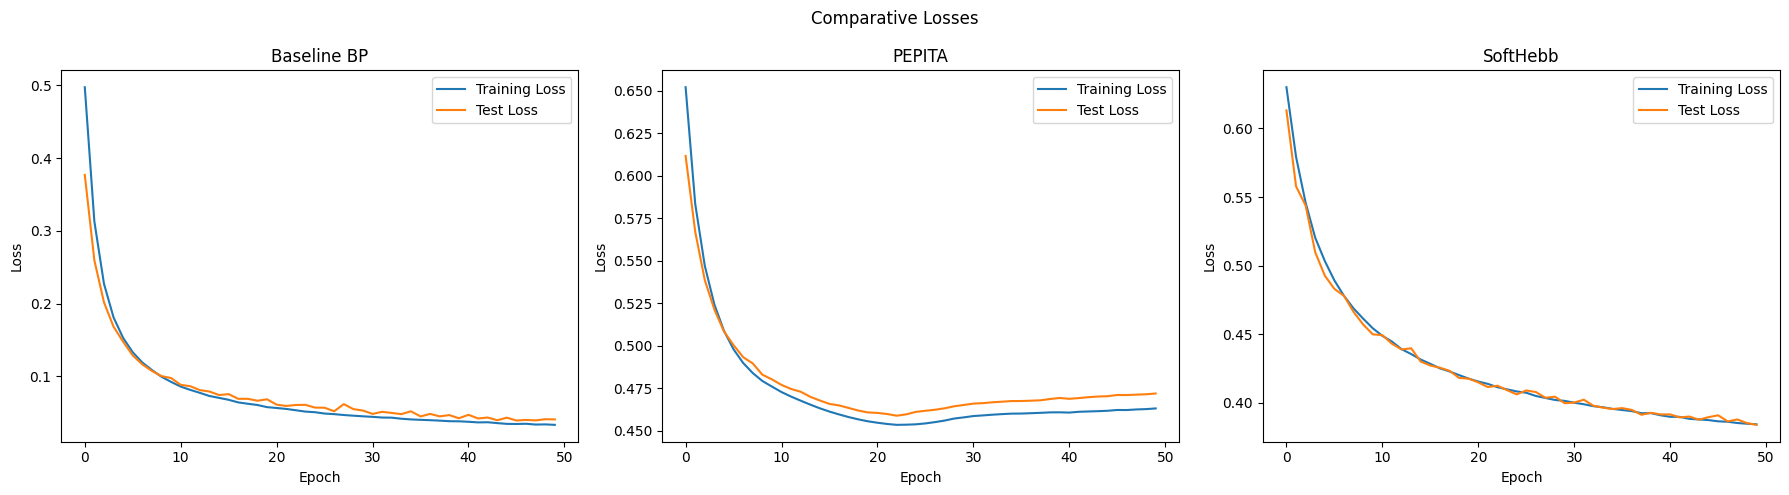

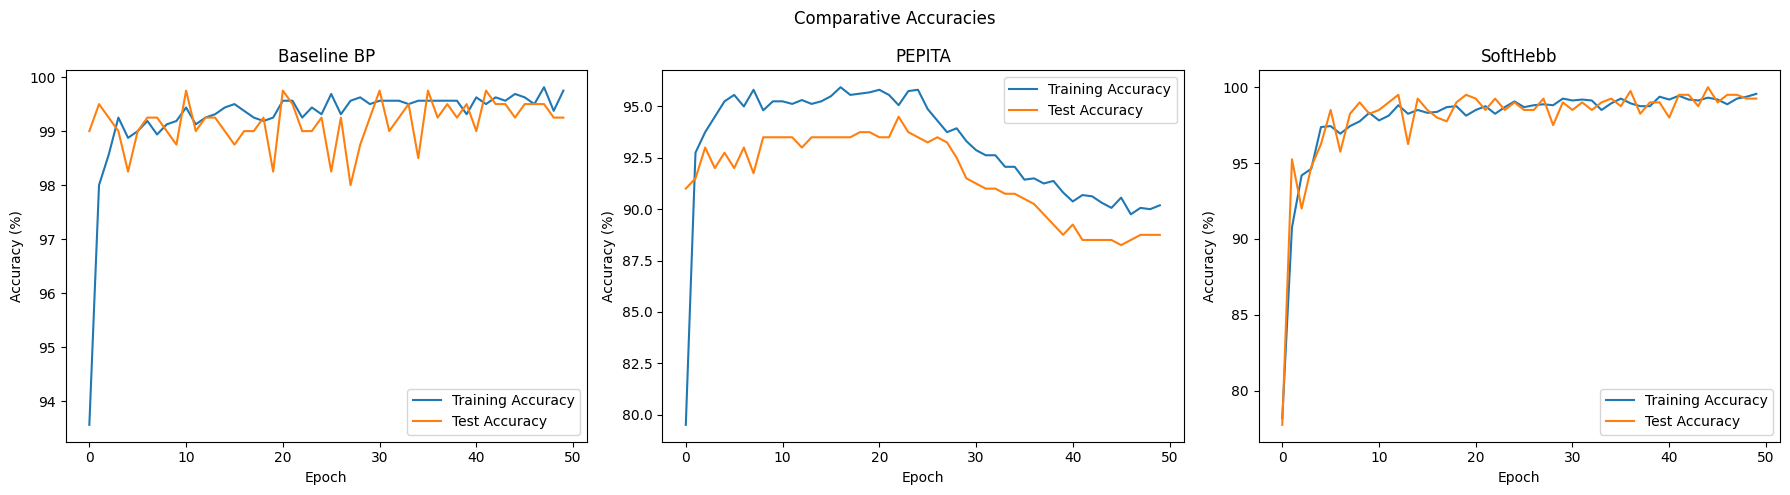

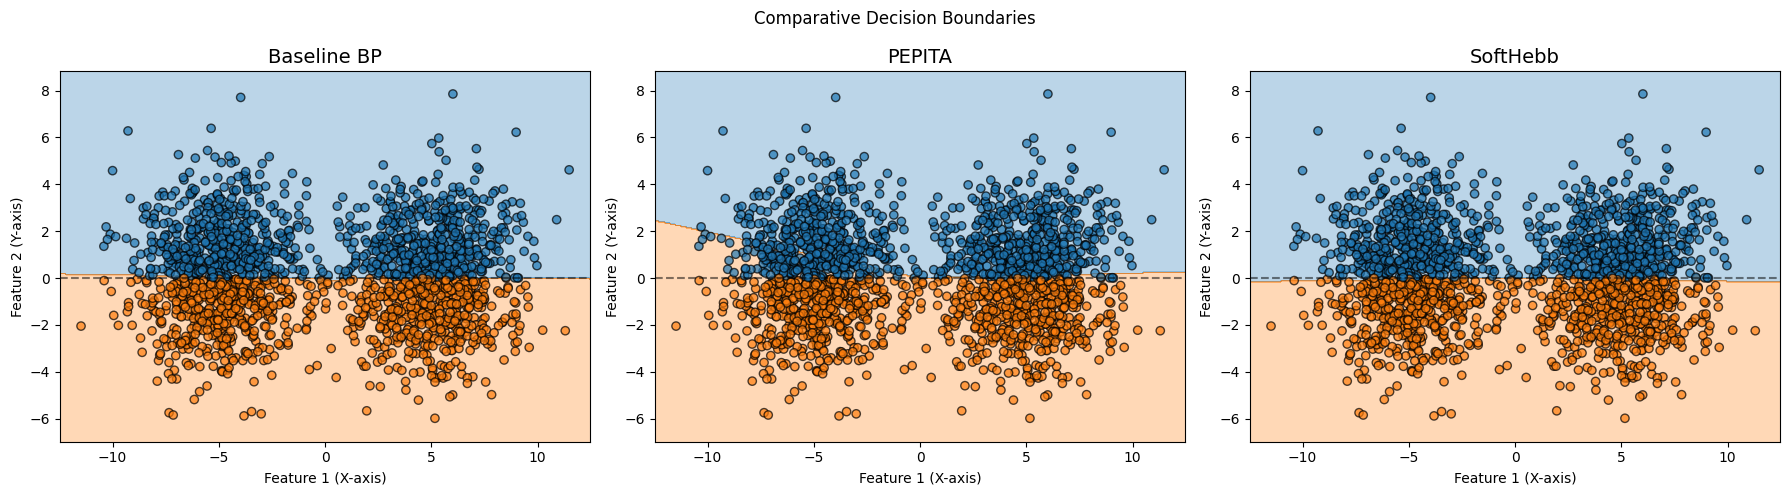

In [6]:
models = [bp_model, pepita_model, softhebb_model]
losses = [[bp_train_loss, bp_test_loss], [pepita_train_loss, pepita_test_loss], [softhebb_train_loss, softhebb_test_loss]]
accuracies = [[bp_train_acc, bp_test_acc], [pepita_train_acc, pepita_test_acc], [softhebb_train_acc, softhebb_test_acc]]
titles = ["Baseline BP", "PEPITA", "SoftHebb"]

plot_comparative_losses(losses, titles)
plot_comparative_accuracies(accuracies, titles)
plot_comparative_boundaries(models, titles, X_train, y_train, X_test, y_test)

## Save the models for the following notebooks

In [7]:
checkpoint_dir = 'checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

torch.save(bp_model.state_dict(), os.path.join(checkpoint_dir, 'bp_weights.pth'))
torch.save(pepita_model.state_dict(), os.path.join(checkpoint_dir, 'pepita_weights.pth'))
torch.save(softhebb_model.state_dict(), os.path.join(checkpoint_dir, 'softhebb_weights.pth'))

dataset_dict = {
    'X_train': X_train,
    'y_train': y_train,
    'X_test': X_test,
    'y_test': y_test
}
torch.save(dataset_dict, os.path.join(checkpoint_dir, 'synthetic_data.pth'))

print(f"Successfully saved 3 models and dataset to ./{checkpoint_dir}/")

Successfully saved 3 models and dataset to ./checkpoints/


## Additional render of dataset for Paper

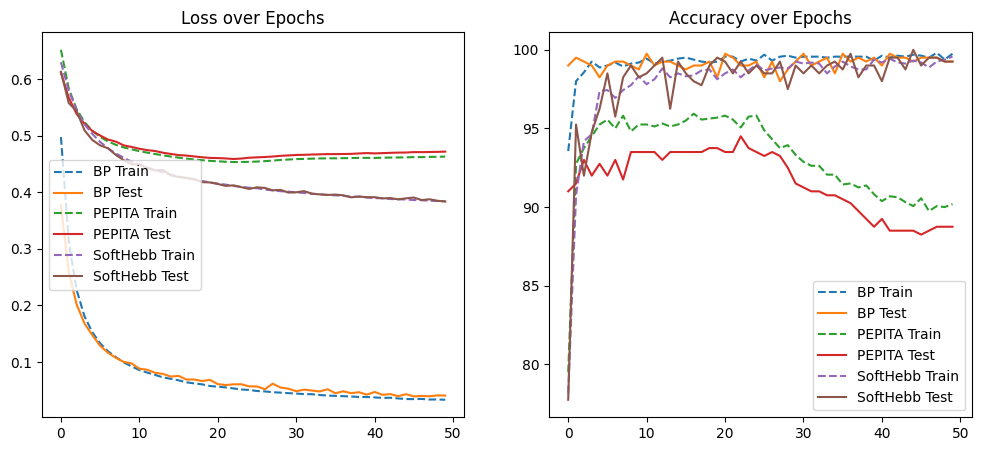

In [8]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(bp_train_loss, label='BP Train', linestyle='--')
plt.plot(bp_test_loss, label='BP Test')
plt.plot(pepita_train_loss, label='PEPITA Train', linestyle='--')
plt.plot(pepita_test_loss, label='PEPITA Test')
plt.plot(softhebb_train_loss, label='SoftHebb Train', linestyle='--')
plt.plot(softhebb_test_loss, label='SoftHebb Test')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(bp_train_acc, label='BP Train', linestyle='--')
plt.plot(bp_test_acc, label='BP Test')
plt.plot(pepita_train_acc, label='PEPITA Train', linestyle='--')
plt.plot(pepita_test_acc, label='PEPITA Test')
plt.plot(softhebb_train_acc, label='SoftHebb Train', linestyle='--')
plt.plot(softhebb_test_acc, label='SoftHebb Test')
plt.title('Accuracy over Epochs')
plt.legend()
os.makedirs('renders', exist_ok=True)
plt.savefig('renders/acc synthetic.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()